# Multilayer Perceptron (MLP)

## Perceptron vs MLP

The single-layer Perceptron can only learn a linear boundary. The **MLP** overcomes this by stacking multiple layers of neurons, each applying a non-linear activation function. With just one hidden layer and a non-linear activation, the network can theoretically approximate any continuous function (Universal Approximation Theorem).

Each hidden layer computes:
$$\mathbf{a}^{(l)} = \phi\!\left(\mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

The non-linearity $\phi$ (typically ReLU: $\max(0,z)$) is what enables curved boundaries.

Training uses **backpropagation**: the chain rule propagates the gradient of the loss backward through every layer, telling each weight how much it contributed to the error.

## 1. Setup & Data Export

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.mlp import MLP
from mlpackage.preprocess import one_hot_encode
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'digits.csv'
if not os.path.exists(CSV_PATH):
    digits = load_digits()
    df_out = pd.DataFrame(digits.data)
    df_out.columns = [f'pixel_{i}' for i in range(64)]
    df_out['target'] = digits.target
    df_out.to_csv(CSV_PATH, index=False)
    print('Dataset exported.')
else:
    print('Dataset already present.')

Dataset already present.


## 2. Data Exploration

In [2]:
df = pd.read_csv(CSV_PATH)
feature_cols = [c for c in df.columns if c != 'target']
X_raw = df[feature_cols].values
y_raw = df['target'].values

print('Shape:', df.shape)
print('Classes:', np.unique(y_raw))
print('Samples per class:', pd.Series(y_raw).value_counts().sort_index().to_dict())

Shape: (1797, 65)
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: {0: 178, 1: 182, 2: 177, 3: 183, 4: 181, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


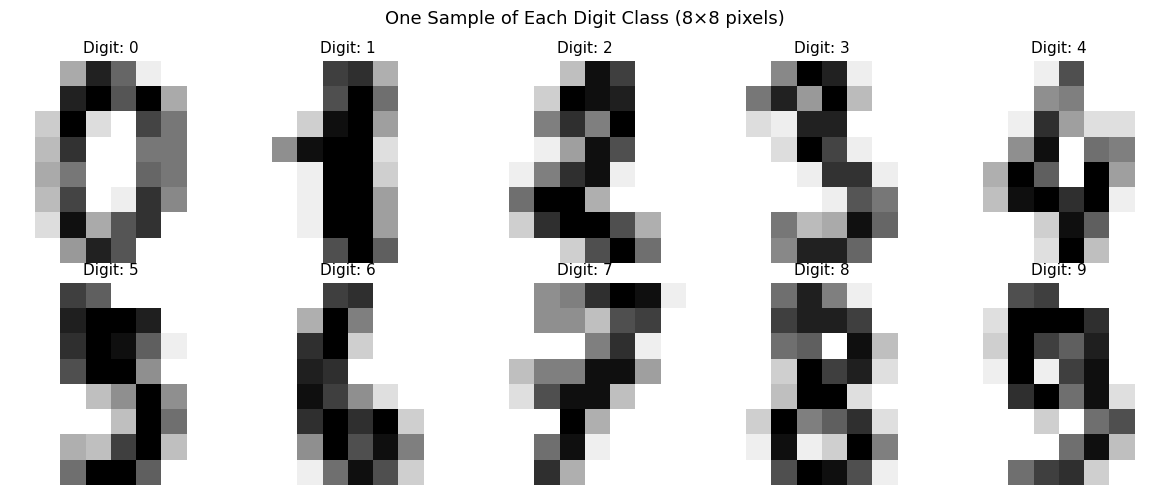

In [3]:
# Show one example of each digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flat):
    idx = np.where(y_raw == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.suptitle('One Sample of Each Digit Class (8×8 pixels)', fontsize=13)
plt.tight_layout()
plt.show()

Each panel is one 8×8 grayscale image, the actual input the MLP receives.  
Darker pixels have higher values (up to 16); white pixels are 0.

Consider digits '3' and '8': both have curves on the right side and look similar in pixel space. A single linear boundary cannot separate them because the distinguishing features (the closed loops of '8') require non-linear combinations of multiple pixels. The MLP learns these combinations automatically through its hidden layers.

## 3. Preprocessing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (1437, 64)  |  Test: (360, 64)


## 4. Training

In [7]:
y_train_oh = one_hot_encode(y_train)
y_test_oh = one_hot_encode(y_test)

model = MLP(
    layer_sizes=[X_train_s.shape[1], 128, 64, 10],
    lr=0.01,
    n_iters=10000
)

model.fit(X_train_s, y_train_oh)

print(f'Train accuracy : {model.score(X_train_s, y_train_oh):.4f}')
print(f'Test  accuracy : {model.score(X_test_s, y_test_oh):.4f}')

Train accuracy : 0.9937
Test  accuracy : 0.9694


## 5. Loss Curve

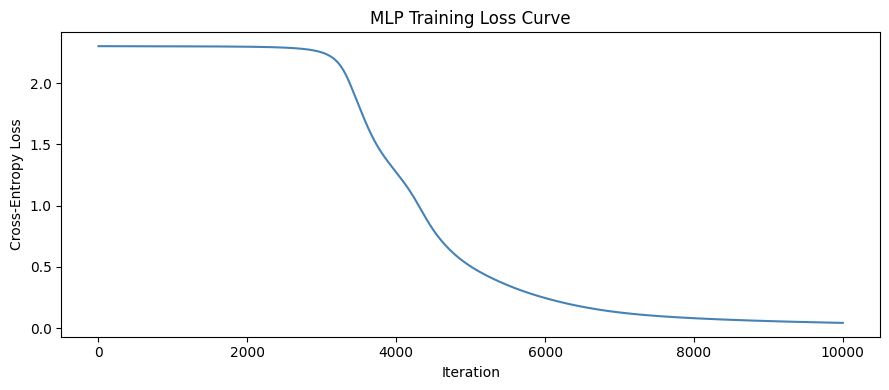

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('MLP Training Loss Curve')
plt.tight_layout()
plt.show()

Initial Plateau (0–3k iterations):  
Loss stays around ~2.3 which shows random guessing for a 10-class problem.    
The model struggles to find useful gradients early on.

Rapid Learning (3k–6k):  
Loss drops sharply (< 0.5).    
The model starts learning key patterns and improves quickly.  

Convergence (6k–10k):  
Loss decreases slowly toward ~0.    
The model stabilizes and reaches near-optimal performance.

## 6. Effect of Architecture — Shallow vs Deep

Training architectures: 100%|██████████| 4/4 [03:18<00:00, 49.53s/it]


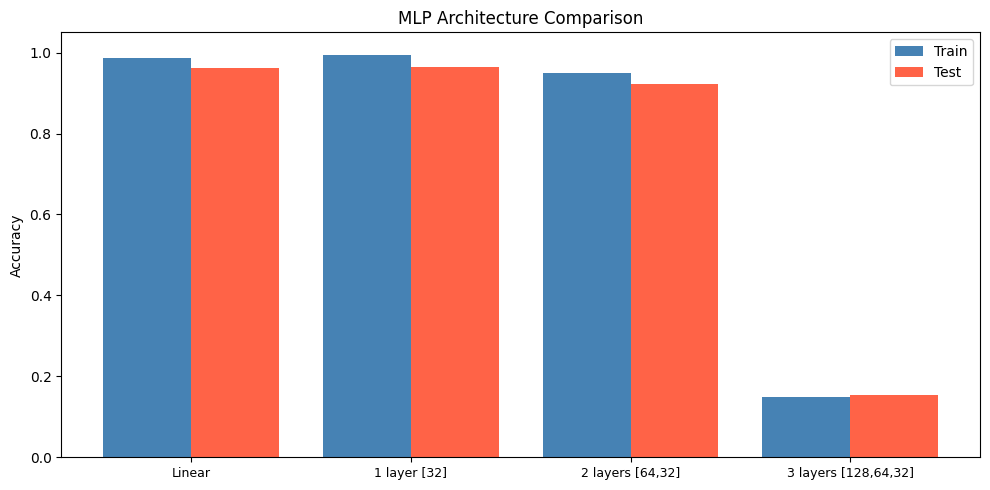

In [14]:
from tqdm import tqdm

architectures = {
    'Linear': [],
    '1 layer [32]': [32],
    '2 layers [64,32]': [64, 32],
    '3 layers [128,64,32]': [128, 64, 32],
}

input_size = X_train_s.shape[1]
output_size = 10

results = {}

y_train_oh = one_hot_encode(y_train)
y_test_oh = one_hot_encode(y_test)

for name, hidden_layers in tqdm(architectures.items(), desc="Training architectures"):
    layer_sizes = [input_size] + hidden_layers + [output_size]

    m = MLP(layer_sizes=layer_sizes, lr=0.01, n_iters=8000)
    m.fit(X_train_s, y_train_oh)

    results[name] = {
        'train': m.score(X_train_s, y_train_oh),
        'test':  m.score(X_test_s, y_test_oh)
    }

names = list(results.keys())
train_accs = [results[n]['train'] for n in names]
test_accs  = [results[n]['test']  for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 0.2, train_accs, 0.4, label='Train', color='steelblue')
ax.bar(x + 0.2, test_accs, 0.4, label='Test', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('MLP Architecture Comparison')
ax.legend()

plt.tight_layout()
plt.show()

At 8000 iterations, the models appear to have largely converged. The 2 layer model plateau around **~90% accuracy**, while the simpler models (no hidden layer and 1 layer) reach near **~100%** performance.

This suggests the deeper model (3 layer) is likely stuck in **sub-optimal local minima**, rather than reaching the best possible solution.

Some possible reasons for that are:
- Vanishing gradients: In deeper networks, gradients shrink as they propagate backward, reducing learning in earlier layers and limiting improvement.
- Over-complexity: The dataset is relatively simple, so shallow models already capture the structure well. Adding more layers introduces unnecessary complexity, making optimization harder.
- Learning rate effects: A learning rate of 0.01 may be too high for deeper architectures, causing unstable updates or preventing fine convergence.

Overall, the results indicate that **increasing model depth does not improve performance for this dataset**, and instead may hinder optimization due to training instability and unnecessary complexity.

## 7. Confusion Matrix

[5 2 8 1 7]


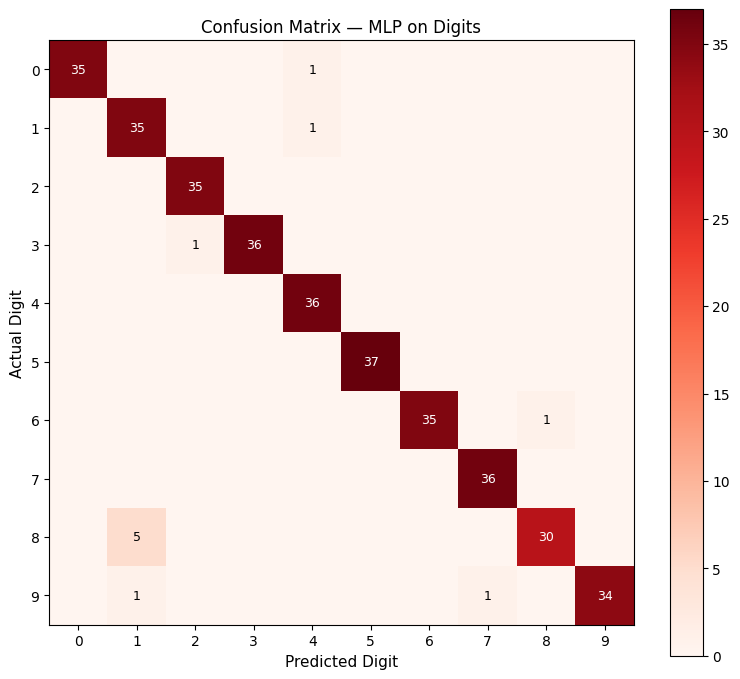

In [15]:
y_pred = model.predict(X_test_s)

print(model.predict(X_test_s)[:5])

if y_pred.ndim > 1:
    y_pred = np.argmax(y_pred, axis=1)

if y_test_oh.ndim > 1:
    y_true = np.argmax(y_test_oh, axis=1)
else:
    y_true = y_test_oh


cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Reds')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted Digit', fontsize=11)
ax.set_ylabel('Actual Digit', fontsize=11)
ax.set_title('Confusion Matrix — MLP on Digits')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            ax.text(
                j, i, cm[i, j],
                ha='center', va='center',
                fontsize=9,
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black'
            )

plt.tight_layout()
plt.show()

Dark diagonal = correct predictions. Off-diagonal = errors.

The most common confusions reveal which digits look similar in pixel space:
- 8 & 1: the thin curves in the 8s make it difficult to tell them apart from the 1s
- 4 & 0/1: sloppy 4s do not have distinct strokes that differentiate it from 0s and 1s

Near-zero off-diagonal cells (e.g., 0 vs 1) confirm that dissimilar digits are almost never confused.

## 8. Misclassified Samples

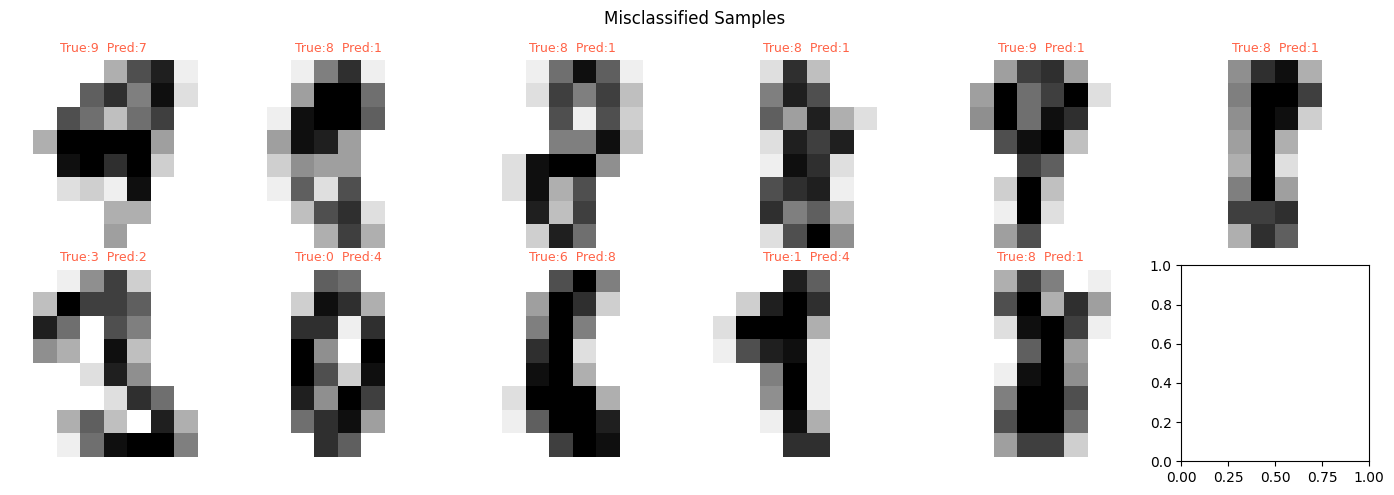

In [16]:
wrong_idx = np.where(y_pred != y_test)[0]
n_show = min(12, len(wrong_idx))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, idx in zip(axes.flat, wrong_idx[:n_show]):
    # Inverse-transform to get original pixel values
    img = scaler.inverse_transform(X_test_s[idx:idx+1])[0]
    ax.imshow(img.reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.set_title(f'True:{y_test[idx]}  Pred:{y_pred[idx]}',
                 fontsize=9, color='tomato')
    ax.axis('off')

plt.suptitle('Misclassified Samples', fontsize=12)
plt.tight_layout()
plt.show()

Each image is a digit the MLP got wrong.

Most misclassifications look genuinely ambiguous even to the human eye. Poorly formed strokes, unusual slants, or noisy pixels. These are the samples that fall near the decision boundary in feature space.

A model's irreducible error comes from samples like these: either the label is correct but the writing is atypical, or the image genuinely resembles multiple classes. Adding more training data or deeper architectures helps but cannot eliminate this ambiguity entirely.

## 9. Key Takeaways

- The **architecture comparison** is the central result: moving from no hidden layer (linear classifier, perceptron) to one hidden layer gives the only positive accuracy jump. This directly demonstrates why depth matters, but too much adds unnecessary complexity.
- The **loss curve** is the training diagnostic: a smooth monotonic descent is healthy. Oscillations mean the learning rate is too large; no descent means it is too small.
- **Misclassified images** confirm that remaining errors are concentrated on ambiguous, atypically-written samples. The model's error is qualitatively reasonable.
- The MLP requires **standardized inputs**: the gradient magnitude is proportional to feature magnitude, and unstandardized pixels (range 0–16) can destabilize training.

## Why MLP?

This dataset is a good example of MLP application because:

- **Non-linear structure is necessary**: a single Perceptron cannot distinguish a '3' from an '8'. The boundary between digit classes is not a hyperplane in pixel space. Multiple non-linear layers are needed to extract spatial patterns.
- **64 features** (8×8 pixels) is high enough that the MLP's ability to learn feature interactions matters, but small enough that training is fast in a notebook.
- **10 classes** requires a softmax output layer and categorical cross-entropy, demonstrating the full multiclass pipeline.
- **Visualizable inputs**: we can display the actual images to see what the model is learning, making errors interpretable.